In [101]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [102]:
# Read words from file
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [103]:
len(words)

32033

In [104]:
# Vocabulary mapping
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [105]:
# Create the dataset of blocks
block_size = 3
X, Y = [], []

for w in words[:5]:
    print(w)
    context = [0] * block_size  # zero context
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(f"{''.join(itos[i] for i in context)} ---> {ch}")
        context = context[1:] + [ix]  # slide context to the right by one

X = torch.tensor(X)
Y = torch.tensor(Y)


emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [106]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

## Embedding

In [ ]:
C = torch.randn((27, 2))  # Embedding table: 27 rows, 2 columns
# thus, X @ C -> row vector of size 2 per character X

In [108]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

## Layer 1

In [109]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [110]:
# concatenate each block in emb along dimension 1 (for input vectors of size 2)
torch.concat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape

torch.Size([32, 6])

In [111]:
# For any block size: torch.unbind removes a dimension (same as above)
torch.concat(torch.unbind(emb, 1), 1).shape  # and concat along the 2nd dimension (dim 1)

torch.Size([32, 6])

In [112]:
emb.view(32, 6).shape

torch.Size([32, 6])

In [113]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [114]:
h.shape

torch.Size([32, 100])

## Layer 2

In [115]:
W2 = torch.randn((100, 27))  # 100 rows, 27 columns
b2 = torch.randn(27)  # converts to 1 row, 27 columns when multiplied

In [116]:
### Layer 2 Calculation
logits = h @ W2 + b2  # (32, 100) @ (100, 27) -> (32, 27)
print(logits.shape)
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)  # convert each row into prob. dist. by dividing by row sums (while preserving dim as rows = 1)
print(prob.shape)

torch.Size([32, 27])
torch.Size([32, 27])


In [117]:
prob

tensor([[6.8005e-10, 1.2032e-16, 7.5356e-08, 4.6379e-10, 2.6983e-07, 7.7927e-10,
         2.1722e-07, 4.1931e-12, 7.7284e-04, 6.1532e-18, 7.2129e-05, 1.5817e-10,
         2.8310e-08, 6.4209e-04, 1.1442e-06, 3.3468e-07, 1.3131e-03, 3.3463e-05,
         3.8155e-04, 3.4016e-07, 1.3180e-05, 2.9784e-15, 1.9591e-07, 2.3058e-10,
         8.9003e-05, 9.9668e-01, 5.8709e-15],
        [3.2302e-11, 1.1922e-16, 1.4323e-06, 5.9733e-09, 1.4051e-06, 3.9913e-10,
         8.3283e-08, 6.6795e-12, 1.6156e-03, 1.3511e-17, 6.7639e-06, 1.6039e-10,
         1.9306e-08, 9.1245e-04, 2.1560e-05, 1.1748e-06, 2.3918e-03, 5.5065e-06,
         2.7703e-05, 8.2710e-09, 3.7130e-06, 1.2588e-14, 3.3612e-07, 5.7524e-10,
         2.4974e-04, 9.9476e-01, 1.6300e-12],
        [4.2958e-09, 5.9922e-16, 5.4504e-07, 1.0455e-07, 8.2825e-07, 1.5997e-11,
         5.3700e-08, 7.0300e-13, 2.5358e-02, 8.3164e-16, 7.9603e-04, 1.8393e-07,
         3.7232e-09, 4.9977e-04, 3.8091e-05, 7.9540e-07, 4.9706e-04, 5.0199e-05,
         1.7224e-

## Loss

In [118]:
### Loss calculated as average negative log likelihood (aka. one-hot cross entropy)
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(18.6675)

## Full Model
(but actually Presentable)

In [ ]:
# For everything
block_size = 3
X, Y = [], []

for w in words:
    context = [0] * block_size  # zero context
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]  # slide context to the right by one

X = torch.tensor(X)
Y = torch.tensor(Y)

In [356]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

### Data Splits

In [667]:
block_size = 5 # context length: how many characters do we take to predict the next one?
dim = 8
context_dim = block_size * dim

In [635]:
# Training split, Dev/Validation split, Test split
# 80%, 10%, 10%
# build the dataset

def build_dataset(words):
    X, Y = [], []
    for w in words:
        
        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '---->', itos[ix])
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182484, 5]) torch.Size([182484])
torch.Size([22869, 5]) torch.Size([22869])
torch.Size([22793, 5]) torch.Size([22793])


In [636]:
Xtr.shape, Ytr.shape

(torch.Size([182484, 5]), torch.Size([182484]))

In [660]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 8), generator=g)
W1 = torch.randn((40, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [661]:
for p in parameters:
    p.requires_grad = True

In [662]:
sum(p.nelement() for p in parameters)  # total number of parameters

20643

In [640]:
lre = torch.linspace(-3, 0, 1000)  # from 1e-3 to 1
lrs = 10**lre

In [691]:
lri = []
lossi = []
stepi = []

In [707]:
for i in range(100000):

    # Minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (64,))  # generates <batch> random indices in X and Y for minibatch

    # Forward pass
    emb = C[Xtr[ix]]  # (32, 2, 3)
    h = torch.tanh(emb.view(-1, context_dim) @ W1 + b1)  # (32, 100)
    logits = h @ W2 + b2  # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])  # nll = cross-entropy loss (PyTorch fused kernel + bundles softmax)
    # print(loss.item())

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update
    # lr = lrs[i]
    lr = 0.001
    for p in parameters:
        p.data += -lr * p.grad

    # Track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

    if i % 10000 == 0:
        print(loss.item())

# loss.item()

2.2216193675994873
1.9838628768920898
1.9687789678573608
2.2658164501190186
2.160752058029175
2.153740406036377
2.046786308288574
2.0469753742218018
2.2148022651672363
2.2630813121795654


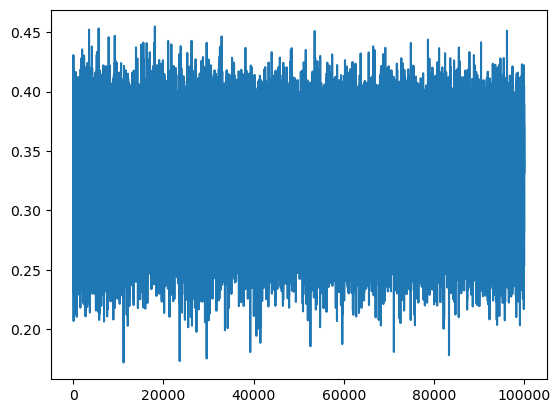

In [708]:
# plt.plot(lri, lossi)  # As we can see, 10^-1 is pretty good, actually.
plt.plot(stepi, lossi)

In [709]:
# Training, used often
emb = C[Xtr]  # (32, 2, 3)
h = torch.tanh(emb.view(-1, context_dim) @ W1 + b1)  # (32, 100)
logits = h @ W2 + b2  # (32, 27)
loss = F.cross_entropy(logits, Ytr)  # nll = cross-entropy loss (PyTorch fused kernel + bundles softmax)
loss

tensor(2.1250, grad_fn=<NllLossBackward0>)

In [710]:
# Validation, used often
emb = C[Xte]  # (32, 2, 3)
h = torch.tanh(emb.view(-1, context_dim) @ W1 + b1)  # (32, 100)
logits = h @ W2 + b2  # (32, 27)
loss = F.cross_entropy(logits, Yte)  # nll = cross-entropy loss (PyTorch fused kernel + bundles softmax)
loss

tensor(2.1590, grad_fn=<NllLossBackward0>)

In [711]:
# Test, used sparingly
emb = C[Xdev]  # (32, 2, 3)
h = torch.tanh(emb.view(-1, context_dim) @ W1 + b1)  # (32, 100)
logits = h @ W2 + b2  # (32, 27)
loss = F.cross_entropy(logits, Ydev)  # nll = cross-entropy loss (PyTorch fused kernel + bundles softmax)
loss

tensor(2.1661, grad_fn=<NllLossBackward0>)

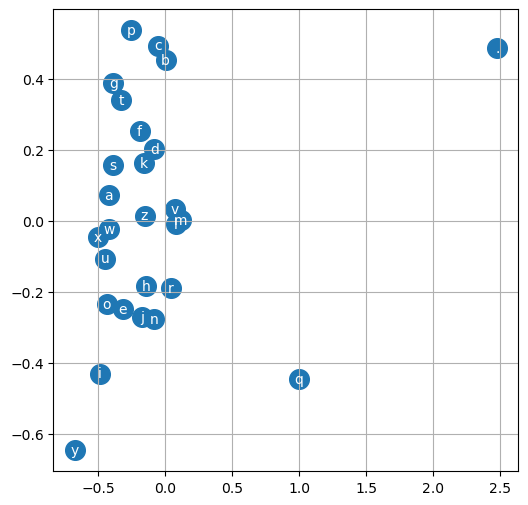

In [ ]:
# Visualize Embedding (for 2D):
plt.figure(figsize=(6,6))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

## Sampling

In [712]:
# Finally, we can sample from the Neural Net; note how the results are very similar to the one with pure counts.
g = torch.Generator().manual_seed(2147483647)

for i in range(100):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]  # (1, block_size, dim)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2  # (32, 27)
        counts = logits.exp()  # compute softmax prob distributions
        probs = counts / counts.sum(1, keepdim=True)  

        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        context = context[1:] + [ix]
        if ix == 0:
            break
    print(''.join(out))

dexze.
momalie.
rochi.
ahnell.
imile.
inrley.
kaman.
arreer.
pubpton.
miota.
miczie.
cavo.
kerted.
jenah.
kamside.
enkavnyn.
rytbe.
mhani.
gavtah.
ashinsor.
breenley.
alaisan.
jarida.
jayzer.
deru.
firit.
gaida.
bhaan.
amal.
kuyaltel.
carira.
ayhar.
envi.
alexa.
maialay.
criste.
ellaiten.
milah.
sahariyanna.
ille.
lahmie.
merah.
amjokael.
morkers.
crestalchah.
cimyn.
alal.
selane.
nechay.
rakon.
shyvia.
isashoure.
chrishya.
johall.
jonnuutetona.
zadia.
radem.
arme.
vilahd.
arayah.
kyh.
ghorry.
kharlli.
lmyza.
ronnnah.
yelen.
aitros.
lolme.
jancl.
dairie.
paydah.
yahlei.
alrie.
tyuriah.
brig.
alkissean.
rena.
raz.
lieina.
calenne.
mikemano.
seadan.
kayren.
rhyss.
fika.
soynn.
michawa.
razhan.
jindelle.
kedarie.
kiha.
denoni.
karnish.
tryton.
marvalina.
alex.
kelsy.
carzora.
gata.
calchika.
